<a href="https://colab.research.google.com/github/minseonju/Marine/blob/main/model/lstm/LSTM_ADFA-LD_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ADFA-LD 관련 코드
import os

DRIVE_PATH = '/content/drive/MyDrive/ADFA_LD'

# 드라이브에 이미 있으면 스킵
if not os.path.exists(DRIVE_PATH):
    print("처음 실행 → 다운로드 시작...")
    !git clone https://github.com/verazuo/a-labelled-version-of-the-ADFA-LD-dataset.git

    import zipfile
    os.makedirs(DRIVE_PATH, exist_ok=True)
    with zipfile.ZipFile('a-labelled-version-of-the-ADFA-LD-dataset/ADFA-LD.zip', 'r') as z:
        z.extractall(DRIVE_PATH)
    print("드라이브 저장 완료")
else:
    print("드라이브에서 로드 git clone 스킵 ")

드라이브에서 로드 git clone 스킵 


In [ ]:
# ADFA-LD 관련 코드
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import (precision_score, recall_score,
                              f1_score, roc_auc_score,
                              confusion_matrix, roc_curve)

# ================================================================
# Config
# ================================================================
config = {
    'base_path'      : f'{DRIVE_PATH}/ADFA-LD',
    'seq_len'        : 100,    # 시퀀스 길이
    'stride'         : 10,     # 윈도우 간격
    'batch_size'     : 256,    # 배치 크기
    'epochs'         : 100,    # 학습 횟수
    'hidden_dim'     : 128,    # 은닉층 크기
    'lr'             : 0.0005, # 학습률
    'weight_decay'   : 1e-5,   # L2 Regularization
    'scheduler_step' : 30,     # LR 감소 주기
    'scheduler_gamma': 0.5,    # LR 감소 비율
    'scaler' : 'standard',     # Normalization
}

scalers = {
    'standard' : StandardScaler(),
    'minmax'   : MinMaxScaler(),
    'robust'   : RobustScaler(),
}
scaler = scalers[config['scaler']]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")
print(f"스케일러: {config['scaler']}")

BASE     = config['base_path']
SEQ_LEN  = config['seq_len']
STRIDE   = config['stride']

# ================================================================
# 데이터 로딩
# ================================================================
def load_sequences(folder, seq_len=SEQ_LEN, stride=STRIDE):
    sequences, labels = [], []
    if not os.path.exists(folder):
        return sequences, labels
    attack_type = os.path.basename(folder)
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        if os.path.isfile(fpath) and fname.endswith('.txt'):
            with open(fpath, 'r') as f:
                nums = list(map(int, f.read().split()))
            for i in range(0, len(nums) - seq_len + 1, stride):
                sequences.append(nums[i:i+seq_len])
                labels.append(attack_type)
    return sequences, labels

print("정상 학습 데이터 로딩...")
normal_seqs, _ = load_sequences(BASE + '/Training_Data_Master')
# Validation 제거 → 정상 22,956개로 줄여서 균형
print(f"정상 시퀀스: {len(normal_seqs)}개")

# 공격 데이터 로딩
attack_seqs, attack_labels = [], []
for attack_type in sorted(os.listdir(BASE + '/Attack_Data_Master')):
    attack_path = os.path.join(BASE + '/Attack_Data_Master', attack_type)
    if os.path.isdir(attack_path):
        seqs, lbls = load_sequences(attack_path)
        attack_seqs.extend(seqs)
        attack_labels.extend(lbls)
print(f"공격 시퀀스: {len(attack_seqs)}개")
print(f"정상:공격 = {len(normal_seqs)}:{len(attack_seqs)} = {len(normal_seqs)/len(attack_seqs):.1f}:1")

# 정규화 (config의 scaler 사용 )
normal_arr = np.array(normal_seqs, dtype=float)
attack_arr = np.array(attack_seqs, dtype=float)
normal_scaled = scaler.fit_transform(normal_arr)
attack_scaled  = scaler.transform(attack_arr)

X_train  = torch.tensor(normal_scaled, dtype=torch.float32).unsqueeze(-1).to(device)
X_attack = torch.tensor(attack_scaled,  dtype=torch.float32).unsqueeze(-1).to(device)
print(f"\n학습 텐서: {X_train.shape}")
print(f"공격 텐서: {X_attack.shape}")

사용 디바이스: cuda
스케일러: standard
정상 학습 데이터 로딩...
정상 시퀀스: 22956개
공격 시퀀스: 24708개
정상:공격 = 22956:24708 = 0.9:1

학습 텐서: torch.Size([22956, 100, 1])
공격 텐서: torch.Size([24708, 100, 1])


In [ ]:
# ================================================================
# 모델 정의
# ================================================================
class LSTM_AE(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, n_features=1,
                 hidden_dim=config['hidden_dim']):
        super(LSTM_AE, self).__init__()
        self.seq_len = seq_len
        self.encoder = nn.LSTM(n_features, hidden_dim,
                               num_layers=2, batch_first=True, dropout=0.2)
        self.decoder = nn.LSTM(hidden_dim, n_features,
                               num_layers=2, batch_first=True, dropout=0.2)

    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        x_rec = hidden[-1].unsqueeze(0).repeat(self.seq_len, 1, 1).transpose(0, 1)
        x_rec, _ = self.decoder(x_rec)
        return x_rec

model     = LSTM_AE().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),
                              lr=config['lr'],
                              weight_decay=config['weight_decay'])
scheduler = torch.optim.lr_scheduler.StepLR(
                optimizer,
                step_size=config['scheduler_step'],
                gamma=config['scheduler_gamma'])

# ================================================================
# 학습
# ================================================================
BATCH_SIZE  = config['batch_size']
EPOCHS      = config['epochs']
train_losses = []

print("학습 시작...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    perm      = torch.randperm(len(X_train))
    X_shuffled = X_train[perm]

    for i in range(0, len(X_shuffled), BATCH_SIZE):
        batch = X_shuffled[i:i+BATCH_SIZE]
        optimizer.zero_grad()
        output = model(batch)
        loss   = criterion(output, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()
    train_losses.append(total_loss / len(X_shuffled) * BATCH_SIZE)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}, Loss: {total_loss:.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")

학습 시작...
Epoch   0, Loss: 82.0697, LR: 0.000500
Epoch  10, Loss: 76.7800, LR: 0.000500
Epoch  20, Loss: 70.9385, LR: 0.000500
Epoch  30, Loss: 59.9937, LR: 0.000250
Epoch  40, Loss: 58.9541, LR: 0.000250
Epoch  50, Loss: 58.4223, LR: 0.000250
Epoch  60, Loss: 57.1440, LR: 0.000125
Epoch  70, Loss: 56.3190, LR: 0.000125
Epoch  80, Loss: 56.1170, LR: 0.000125
Epoch  90, Loss: 55.9262, LR: 0.000063


In [ ]:
# ================================================================
# Reconstruction Error 계산
# ================================================================
model.eval()
with torch.no_grad():
    normal_errors = []
    for i in range(0, len(X_train), BATCH_SIZE):
        batch = X_train[i:i+BATCH_SIZE]
        pred  = model(batch)
        err   = torch.mean((pred - batch)**2, dim=(1,2))
        normal_errors.extend(err.cpu().numpy())
    normal_errors = np.array(normal_errors)

    attack_errors = []
    for i in range(0, len(X_attack), BATCH_SIZE):
        batch = X_attack[i:i+BATCH_SIZE]
        pred  = model(batch)
        err   = torch.mean((pred - batch)**2, dim=(1,2))
        attack_errors.extend(err.cpu().numpy())
    attack_errors = np.array(attack_errors)

print(f"정상 오차 - mean: {normal_errors.mean():.6f}, std: {normal_errors.std():.6f}")
print(f"공격 오차 - mean: {attack_errors.mean():.6f}, std: {attack_errors.std():.6f}")
print(f"오차 차이: {attack_errors.mean() - normal_errors.mean():.6f}")

# ================================================================
# 임계값 탐색 (F1 최적화 + Youden's J 비교)
# ================================================================
all_errors = np.concatenate([normal_errors, attack_errors])
y_true     = np.array([0]*len(normal_errors) + [1]*len(attack_errors))

# F1 최적화
best_t, best_f1 = 0, 0
for pct in np.arange(50, 99, 0.5):
    t    = np.percentile(normal_errors, pct)
    pred = (all_errors > t).astype(int)
    f1   = f1_score(y_true, pred, average='macro')
    if f1 > best_f1:
        best_f1, best_t = f1, t

# Youden's J
fpr_arr, tpr_arr, thresholds_roc = roc_curve(y_true, all_errors)
J         = tpr_arr - fpr_arr
youden_t  = thresholds_roc[np.argmax(J)]

print(f"\nF1 최적화 임계값:  {best_t:.6f}  (macro F1: {best_f1:.4f})")
print(f"Youden's J 임계값: {youden_t:.6f}  (TPR: {tpr_arr[np.argmax(J)]:.4f}, FPR: {fpr_arr[np.argmax(J)]:.4f})")

# 최종 임계값 선택 (F1 최적화 사용)
threshold = best_t

# ================================================================
# 성능 평가
# ================================================================
y_pred = (all_errors > threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
print(f"\n=== 성능 평가 ===")
print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
print(f"FPR:       {fp/(fp+tn):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_true, all_errors):.4f}")

# 공격 유형별 탐지율
print("\n[공격 유형별 탐지율]")
attack_label_arr = np.array(attack_labels)
for atype in sorted(set(attack_labels)):
    mask     = attack_label_arr == atype
    detected = np.sum(attack_errors[mask] > threshold)
    total    = np.sum(mask)
    print(f"  {atype:25s}: {detected}/{total} ({detected/total*100:.1f}%)")

정상 오차 - mean: 0.617261, std: 0.394273
공격 오차 - mean: 0.875737, std: 0.402686
오차 차이: 0.258477

F1 최적화 임계값:  0.952854  (macro F1: 0.6642)
Youden's J 임계값: 0.976974  (TPR: 0.4738, FPR: 0.1093)

=== 성능 평가 ===
TP: 12213, TN: 19857, FP: 3099, FN: 12495
Precision: 0.7976
Recall:    0.4943
F1-Score:  0.6103
FPR:       0.1350
AUC-ROC:   0.6958

[공격 유형별 탐지율]
  Adduser_1                : 188/378 (49.7%)
  Adduser_10               : 81/261 (31.0%)
  Adduser_2                : 244/386 (63.2%)
  Adduser_3                : 137/280 (48.9%)
  Adduser_4                : 152/330 (46.1%)
  Adduser_5                : 66/269 (24.5%)
  Adduser_6                : 67/201 (33.3%)
  Adduser_7                : 42/214 (19.6%)
  Adduser_8                : 37/218 (17.0%)
  Adduser_9                : 320/797 (40.2%)
  Hydra_FTP_1              : 75/149 (50.3%)
  Hydra_FTP_10             : 108/222 (48.6%)
  Hydra_FTP_2              : 126/324 (38.9%)
  Hydra_FTP_3              : 252/607 (41.5%)
  Hydra_FTP_4              

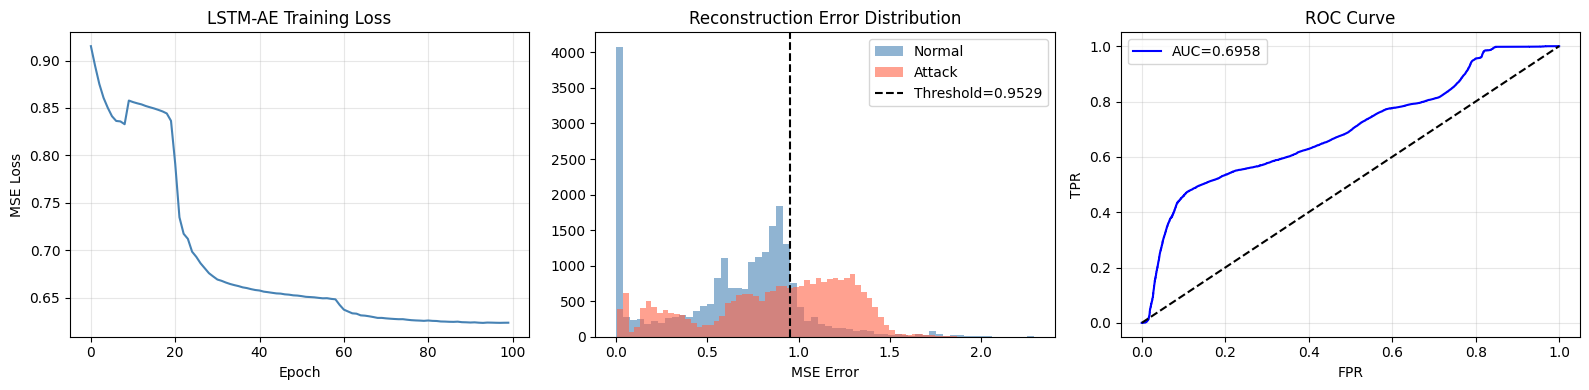

파일: model/lstm_ae.pth / scaler.pkl / threshold.npy


In [ ]:
# ================================================================
# 시각화
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(train_losses, color='steelblue')
axes[0].set_title('LSTM-AE Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(True, alpha=0.3)

axes[1].hist(normal_errors, bins=60, alpha=0.6, label='Normal', color='steelblue')
axes[1].hist(attack_errors, bins=60, alpha=0.6, label='Attack', color='tomato')
axes[1].axvline(threshold, color='black', linestyle='--',
                label=f'Threshold={threshold:.4f}')
axes[1].set_title('Reconstruction Error Distribution')
axes[1].set_xlabel('MSE Error')
axes[1].legend()

axes[2].plot(fpr_arr, tpr_arr, color='blue',
             label=f'AUC={roc_auc_score(y_true, all_errors):.4f}')
axes[2].plot([0,1], [0,1], 'k--')
axes[2].set_xlabel('FPR')
axes[2].set_ylabel('TPR')
axes[2].set_title('ROC Curve')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('adfa_lstm_ae_result.png', dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# 모델 저장
# ================================================================
os.makedirs('model', exist_ok=True)
torch.save(model.state_dict(), 'model/lstm_ae.pth')
with open('model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
np.save('model/threshold.npy', threshold)
np.save('model/normal_err_stats.npy',
        np.array([normal_errors.mean(), normal_errors.std(),
                  normal_errors.min(), normal_errors.max()]))

print("파일: model/lstm_ae.pth / scaler.pkl / threshold.npy")